### Exploratory Data Analyst para dataset de *neighbourhoods*

### 📋 Descripción del Dataset: `neighbourhoods.csv` (Málaga)

El dataset contiene los distritos municipales de la ciudad de **Málaga**. Este archivo servirá como base para categorizar la ubicación de los alojamientos en nuestro pipeline.

| # | neighbourhood_group | neighbourhood |
|:---:|:---:|:---|
| 0 | NaN | Bailen-Miraflores |
| 1 | NaN | Campanillas |
| 2 | NaN | Carretera de Cadiz |
| 3 | NaN | Centro |
| 4 | NaN | Churriana |
| 5 | NaN | Ciudad Jardin |
| 6 | NaN | Cruz De Humilladero |
| 7 | NaN | Este |
| 8 | NaN | Palma-Palmilla |
| 9 | NaN | Puerto de la Torre |
| 10 | NaN | Teatinos-Universidad |

---

### 🔍 Diagnóstico Inicial del EDA

1. **Datos Faltantes:** Al igual que en otros datasets de Airbnb, `neighbourhood_group` está vacío (**11 nulos**). Esto nos permite proponer una tarea de **Transformación** en Airflow para agrupar los distritos por zonas geográficas.
2. **Consistencia:** Los nombres siguen la nomenclatura oficial de distritos de Málaga. Se validará que no existan errores de formato en la carga.
3. **Propuesta de Valor:** Clasificaremos los distritos en **"Litoral"** (con acceso a costa) e **"Interior"**, o por zonas (Centro, Oeste, Este, Periferia) para enriquecer el análisis.

In [2]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

path = "../data/"

neighbourhoods = pd.read_csv(os.path.join(path, "neighbourhoods.csv"))

print(neighbourhoods.head(5), "\n")

print(neighbourhoods.info())


   neighbourhood_group       neighbourhood
0                  NaN   Bailen-Miraflores
1                  NaN         Campanillas
2                  NaN  Carretera de Cadiz
3                  NaN              Centro
4                  NaN           Churriana 

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  0 non-null      float64
 1   neighbourhood        11 non-null     str    
dtypes: float64(1), str(1)
memory usage: 308.0 bytes
None


In [3]:
# Ver cuantos barrios unicos hay
barrios_unicos = neighbourhoods["neighbourhood"].unique()
print(len(barrios_unicos), "barrios únicos\n")
print(barrios_unicos)


11 barrios únicos

<StringArray>
[   'Bailen-Miraflores',          'Campanillas',   'Carretera de Cadiz',
               'Centro',            'Churriana',        'Ciudad Jardin',
  'Cruz De Humilladero',                 'Este',       'Palma-Palmilla',
   'Puerto de la Torre', 'Teatinos-Universidad']
Length: 11, dtype: str


In [4]:
# Ver si hay columnas totalmente vacías (Missing values)
print("\n- Informe de Valores Nulos")
print(neighbourhoods.isnull().sum())


- Informe de Valores Nulos
neighbourhood_group    11
neighbourhood           0
dtype: int64


In [5]:
# Cargar listings y cruzarlos con neighbourhoods
listings = pd.read_csv(os.path.join(path, "listings.csv"))

# Listings por barrio
listings_por_barrio = listings["neighbourhood"].value_counts().reset_index()
listings_por_barrio.columns = ["neighbourhood", "n_listings"]

print(listings_por_barrio.to_string(index=False))

       neighbourhood  n_listings
              Centro        6389
                Este         989
  Carretera de Cadiz         935
 Cruz De Humilladero         460
   Bailen-Miraflores         312
      Palma-Palmilla         217
           Churriana         150
Teatinos-Universidad         100
       Ciudad Jardin          88
  Puerto de la Torre          41
         Campanillas          33


/tmp/ipykernel_10076/2312081826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


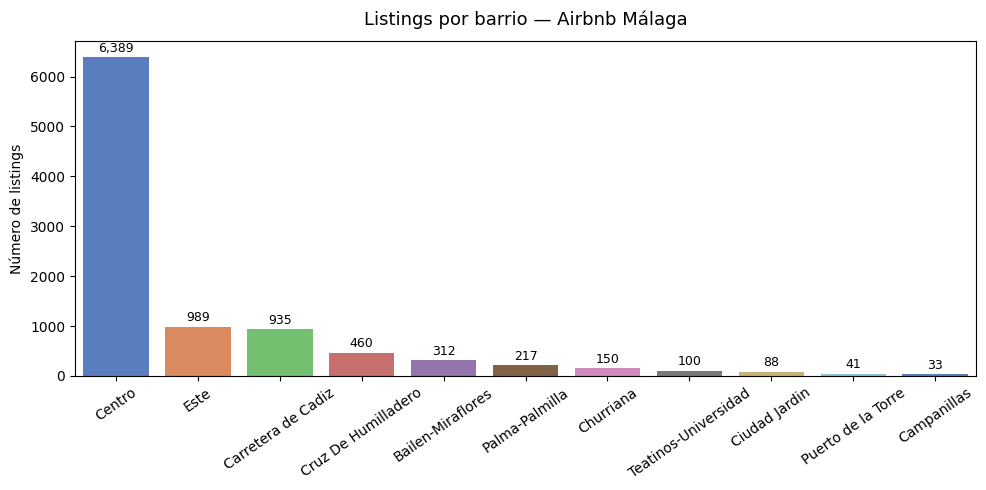

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

barrios_ord = listings_por_barrio.sort_values("n_listings", ascending=False)

sns.barplot(
    data=barrios_ord,
    x="neighbourhood",
    y="n_listings",
    palette="muted",
    ax=ax
)

ax.set_title("Listings por barrio — Airbnb Málaga", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Número de listings")
ax.tick_params(axis="x", rotation=35)

# Etiquetas encima de cada barra
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

In [8]:
# Comprobamos que los barrios coincidan
barrios_csv     = set(neighbourhoods["neighbourhood"].str.strip())
barrios_listing = set(listings["neighbourhood"].dropna().str.strip().unique())

print("En CSV pero NO en listings:", barrios_csv - barrios_listing)
print("En listings pero NO en CSV:", barrios_listing - barrios_csv)
# Si ambos salen vacíos, perfecta consistencia entre ficheros

En CSV pero NO en listings: set()
En listings pero NO en CSV: set()


In [ ]:
# Vemos estadísiticas del precio por barrio

precio_por_barrio = (
    listings.groupby("neighbourhood")["price"]
    .agg(
        precio_medio="mean",
        precio_mediano="median",
        precio_min="min",
        precio_max="max"
    ).round(1).reset_index().sort_values("precio_mediano", ascending=False)
)

print(precio_por_barrio.to_string(index=False))

       neighbourhood  precio_medio  precio_mediano  precio_min  precio_max
         Campanillas        2762.9           250.0        44.0      9143.0
      Palma-Palmilla         137.3           124.0        21.0       926.0
           Churriana         695.8           117.0        27.0      9999.0
                Este         502.0           108.0        22.0     10032.0
              Centro         215.4           105.0        17.0     21911.0
  Puerto de la Torre         408.6            99.0        27.0      9000.0
  Carretera de Cadiz         298.5            95.0        18.0     11412.0
Teatinos-Universidad         364.2            88.0        20.0      9999.0
 Cruz De Humilladero         311.1            87.0        18.0     10000.0
   Bailen-Miraflores         540.6            76.0        18.0     92150.0
       Ciudad Jardin         247.9            61.5        16.0     10000.0


/tmp/ipykernel_10076/602683691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


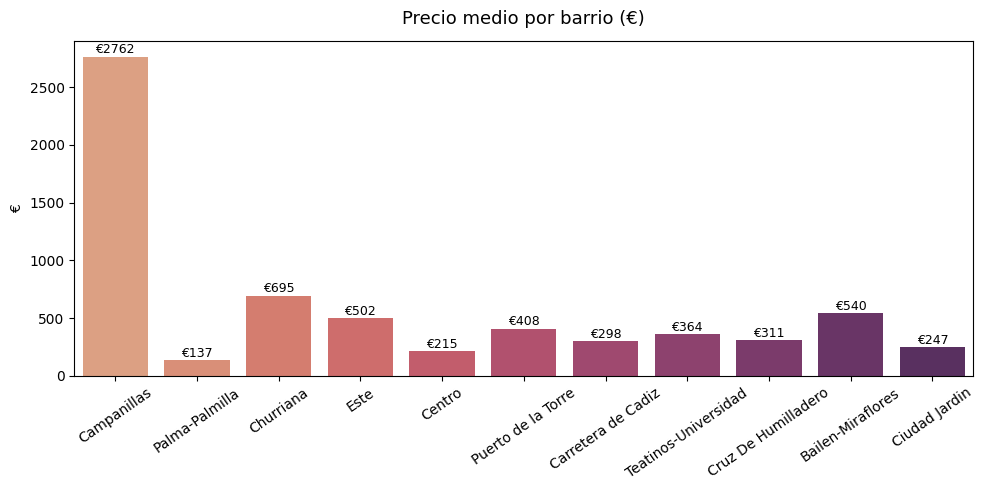

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=precio_por_barrio,
    x="neighbourhood",
    y="precio_medio",
    palette="flare",
    ax=ax
)

ax.set_title("Precio medio por barrio (€)", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("€")
ax.tick_params(axis="x", rotation=35)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"€{int(bar.get_height())}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

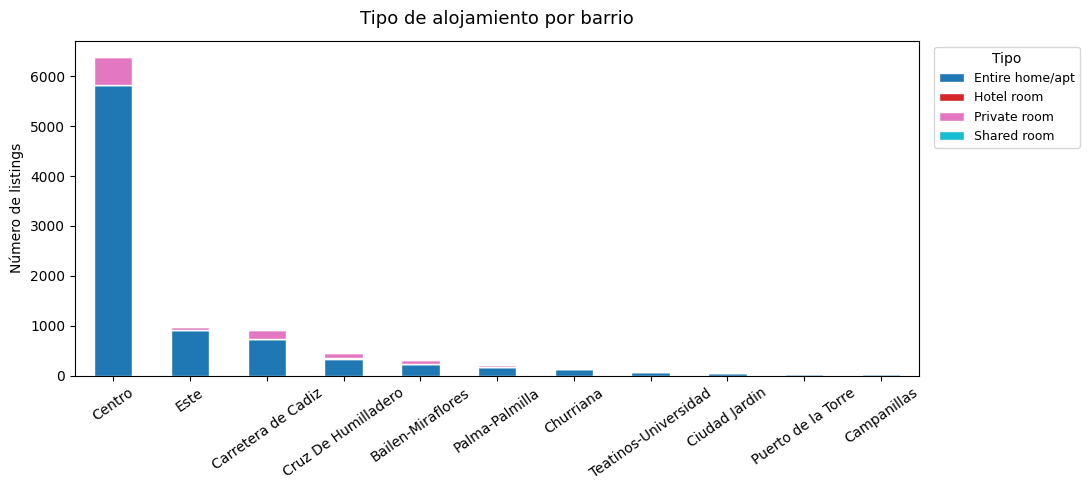

In [20]:
room_type = (
    listings.groupby(["neighbourhood", "room_type"])
    .size()
    .unstack(fill_value=0)
)

# Ordenar por total de listings
room_type = room_type.loc[
    room_type.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(11, 5))
room_type.plot(kind="bar", stacked=True, ax=ax,
               colormap="tab10", edgecolor="white")

ax.set_title("Tipo de alojamiento por barrio", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Número de listings")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Tipo", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

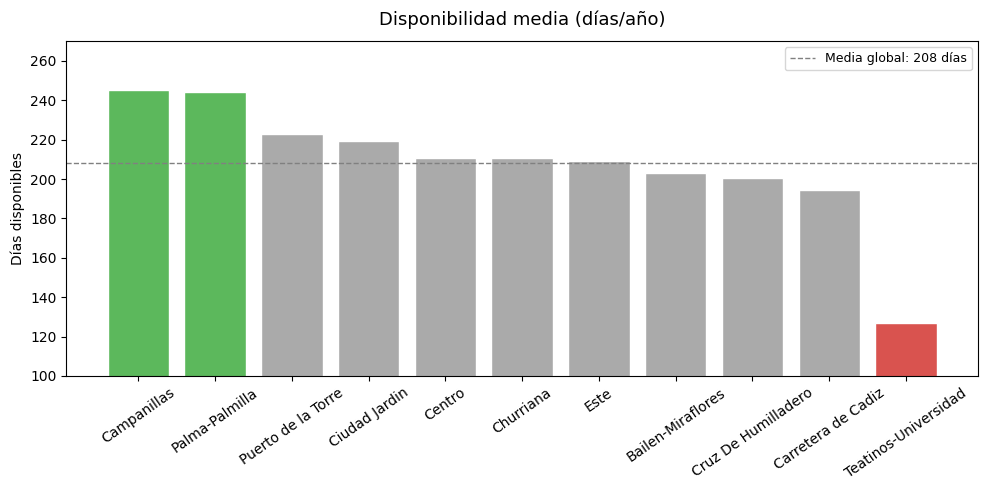

In [28]:
disponibilidad = (
    listings.groupby("neighbourhood")["availability_365"]
    .mean()
    .round(1)
    .reset_index()
    .rename(columns={"availability_365": "disponibilidad_media"})
    .sort_values("disponibilidad_media", ascending=False)
)

# Color por nivel
colores = [
    "#d9534f" if v < 150 else "#5cb85c" if v > 230 else "#aaaaaa"
    for v in disponibilidad["disponibilidad_media"]
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    disponibilidad["neighbourhood"],
    disponibilidad["disponibilidad_media"],
    color=colores, edgecolor="white"
)

media_global = disponibilidad["disponibilidad_media"].mean()
ax.axhline(media_global, color="gray", linestyle="--",
           linewidth=1, label=f"Media global: {media_global:.0f} días")

ax.set_title("Disponibilidad media (días/año)", fontsize=13, pad=12)
ax.set_ylabel("Días disponibles")
ax.set_ylim(100, 270)
ax.tick_params(axis="x", rotation=35)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()